In [1]:
import os
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.messages import AIMessage, HumanMessage
from langchain.agents.format_scratchpad.openai_tools import (
    format_to_openai_tool_messages,
)
from langchain.agents.output_parsers.openai_tools import OpenAIToolsAgentOutputParser
from langchain.agents import AgentExecutor

In [2]:
from tools.continuum import CASolidTool, MCAnnealingTool

In [3]:
OPENAI_API = os.getenv("OPENAI_API")
llm = ChatOpenAI(model="gpt-3.5-turbo", temperature=0, api_key=OPENAI_API)

tools = [
    CASolidTool(),
    MCAnnealingTool()
]
MEMORY_KEY = "chat_history"
prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """
            You are powerful agent for performing cellular automata solidification and Monte Carlo Annealing simulation.
            Before executing any functions list the functions along with their parameters and why you have chosen them.
            """
        ),
        MessagesPlaceholder(variable_name=MEMORY_KEY),
        ("user", "{input}"),
        MessagesPlaceholder(variable_name="agent_scratchpad"),
    ]
)
llm_with_tools = llm.bind_tools(tools)

agent = (
    {
        "input": lambda x: x["input"],
        "agent_scratchpad": lambda x: format_to_openai_tool_messages(
            x["intermediate_steps"]
        ),
        "chat_history": lambda x: x["chat_history"],
    }
    | prompt
    | llm_with_tools
    | OpenAIToolsAgentOutputParser()
)

agent_executor = AgentExecutor(agent=agent, tools=tools, verbose=True)

c:\Users\619ar\anaconda3\envs\mat-proj\Lib\site-packages\pydantic\json_schema.py:2191: PydanticJsonSchemaWarning: Default value (FieldInfo(annotation=NoneType, required=True, description='width of the NxN grid on which simulation takes place'),) is not JSON serializable; excluding default from JSON schema [non-serializable-default]
  warnings.warn(message, PydanticJsonSchemaWarning)




> Entering new AgentExecutor chain...

Invoking: `CellularAutomataPhaseTransform` with `{'width': 100, 'attach_prob': 0.2, 'num_solid_states': 3, 'num_nuclei': 5}`




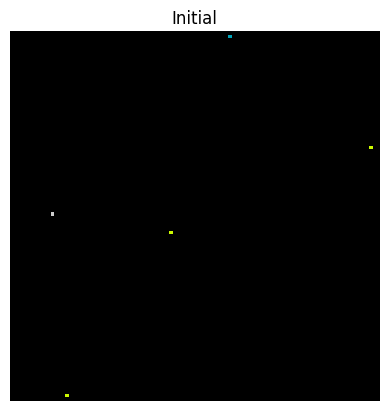

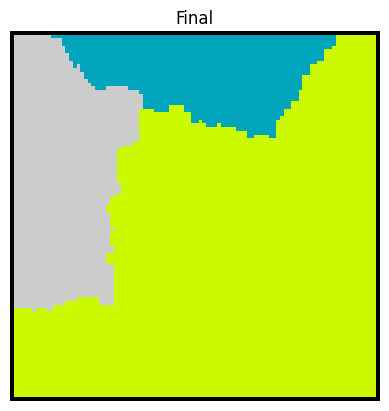

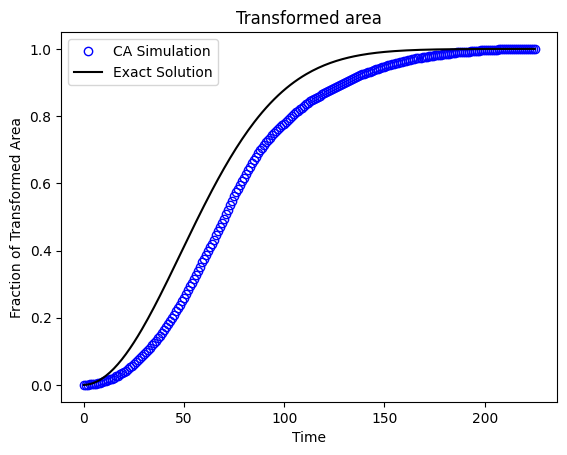

NoneThe simulation for the solidification of an Al-Cu-Mg alloy system using a Cellular Automata model on a 100x100 grid with an attachment probability of 0.2 has been initiated. The system is set to have 3 solid states and 5 initial nuclei for the transformation process.

> Finished chain.


In [4]:
chat_history = []

input1 = """
Simulate the solidification of an Al-Cu-Mg alloy system using a Cellular Automata (CA) model. 
The system should be modeled on a square domain with a width of 100 grid units to ensure adequate 
resolution of microstructural features and multi-phase interactions. Set the attachment probability 
to 0.2, representing realistic diffusion-controlled growth processes for metallic systems under 
typical cooling rates.
"""
result = agent_executor.invoke({"input": input1, "chat_history": chat_history})
chat_history.extend(
    [
        HumanMessage(content=input1),
        AIMessage(content=result["output"]),
    ]
)



> Entering new AgentExecutor chain...

Invoking: `CellularAutomataPhaseTransform` with `{'width': 150, 'attach_prob': 0.9, 'num_solid_states': 2, 'num_nuclei': 50}`




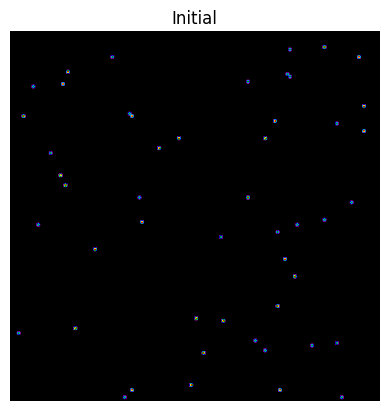

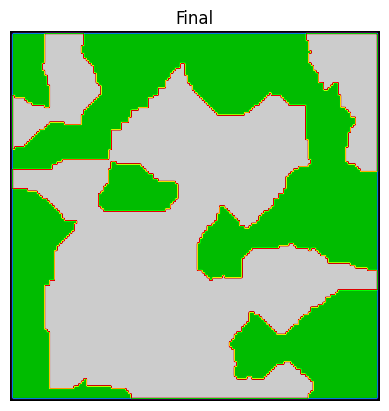

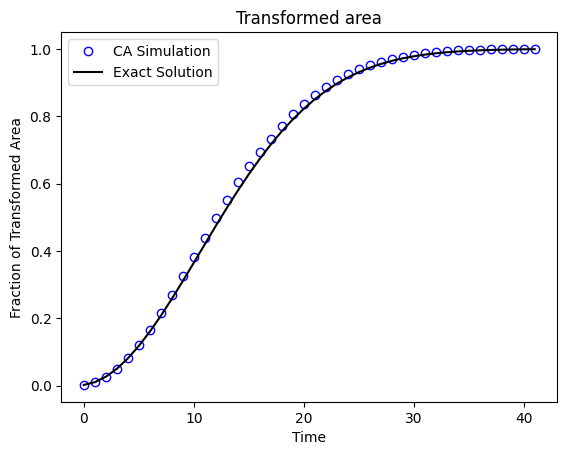

NoneThe simulation for the solidification of a Ti-Al intermetallic alloy using a Cellular Automata model with the specified parameters has been initiated. The grid size is set to 150x150, the attachment probability is 0.9 to favor interface-controlled growth, and there are 50 nuclei per unit area for controlled nucleation. This setup aims to promote smooth, isotropic solidification fronts with minimal dendritic branching.

> Finished chain.


In [5]:
chat_history = []

input1 = """
Simulate the solidification of a Ti-Al intermetallic alloy using a Cellular Automata (CA) model. 
Utilize a grid size of 150x150 for a compact domain while ensuring sufficient resolution of microstructural features. 
Set the nucleation density to 50 nuclei per unit area to represent controlled nucleation. Model the attachment 
probability to favor interface-controlled growth, promoting smooth, isotropic solidification fronts with minimal 
dendritic branching, characteristic of high attachment rates under rapid thermal gradients.
"""
result = agent_executor.invoke({"input": input1, "chat_history": chat_history})
chat_history.extend(
    [
        HumanMessage(content=input1),
        AIMessage(content=result["output"]),
    ]
)



> Entering new AgentExecutor chain...

Invoking: `BiasedPottsMonteCarloAnnealing` with `{'Q': 20, 'L': 50, 'MC_steps': 100, 'biasing_strategy': 3}`




100%|██████████| 100/100 [00:28<00:00,  3.50it/s]


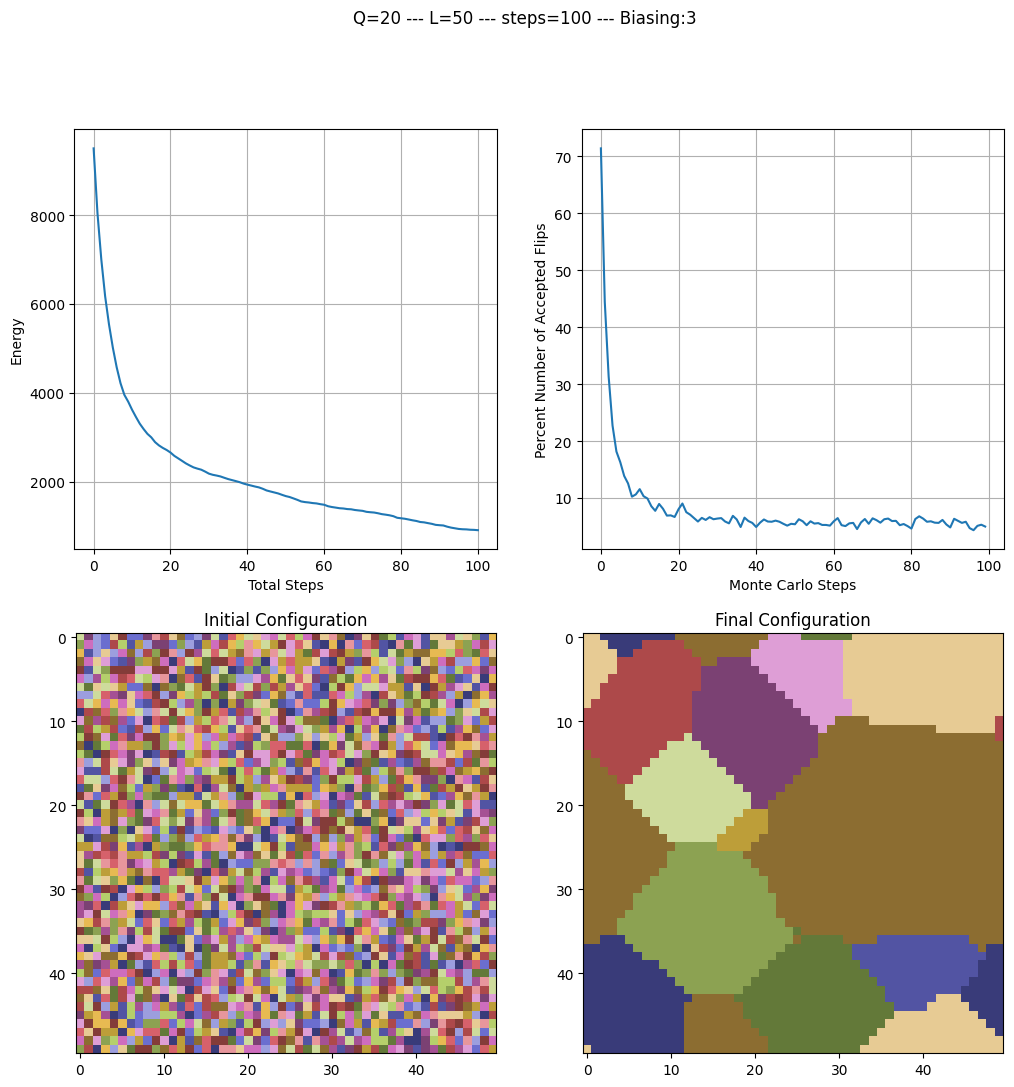

NoneThe simulation for grain growth in a polycrystalline aluminum sample using Monte Carlo annealing has been initiated. The simulation will run for 100 Monte Carlo steps on a 50x50 lattice grid with 20 possible grain orientations. Updates will focus on interface sites to simulate energy reduction at grain boundaries. Snapshots of the lattice will be captured at regular intervals to observe the evolution of the grain structure.

> Finished chain.


In [4]:
chat_history = []

input = """
Using Monte Carlo annealing at T ≈ 0 simulate grain growth in a polycrystalline aluminum sample,
to model the minimization of grain boundary energy during annealing. Use a
50x50 lattice grid, with each site representing a distinct grain orientation chosen from 20 possible flavors.
Begin by initializing the lattice with random grain orientations and identifying grain boundaries. 
Focus updates on interface sites, where neighboring grains meet, to simulate energy reduction at grain boundaries. 
Perform 100 Monte Carlo steps, dynamically tracking and updating the positions of interface sites to reflect grain coarsening. 
Capture snapshots of the lattice at regular intervals to observe the evolution of grain structure, 
including the growth of larger grains at the expense of smaller ones. 
"""
result = agent_executor.invoke({"input": input, "chat_history": chat_history})
chat_history.extend(
    [
        HumanMessage(content=input),
        AIMessage(content=result["output"]),
    ]
)